In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
data = pd.read_csv("../data/Dataset.txt", sep="\t")

In [9]:
data.columns = [
    "Age", "Sex", "Year", "Race", "Cancer_Type",
    "Stage", "Survival_Months", "Vital_Status", "Income"
]

In [10]:
data["Survival_Months"] = pd.to_numeric(data["Survival_Months"], errors="coerce")

def convertir_age(age_range):

    if pd.isna(age_range):
        return np.nan

    age_range = age_range.replace(" years", "")

    partes = age_range.split("-")

    if len(partes) == 2:

        inicio = int(partes[0])
        fin = int(partes[1])

        return (inicio + fin) / 2

    return np.nan

def convertir_income(income_range):

    if pd.isna(income_range):
        return np.nan

    income_range = income_range.replace(",", "")

    partes = income_range.split(" - ")

    if len(partes) == 2:

        inicio = int(partes[0])
        fin = int(partes[1])

        return (inicio + fin) / 2

    return np.nan


data["Income"] = data["Income"].str.replace("$", "", regex=False)
data["Income"] = data["Income"].apply(convertir_income)

print(data["Income"].head())


data["Age"] = data["Age"].apply(convertir_age)

print(data["Age"].head())

0    114999.5
1    104999.5
2    104999.5
3    104999.5
4         NaN
Name: Income, dtype: float64
0    17.0
1    17.0
2    12.0
3    12.0
4    17.0
Name: Age, dtype: float64


In [11]:
data = data[data["Stage"] != "Blank(s)"]
data = data.dropna()

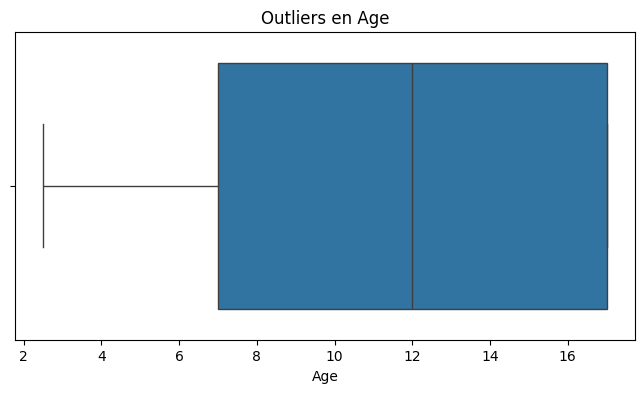

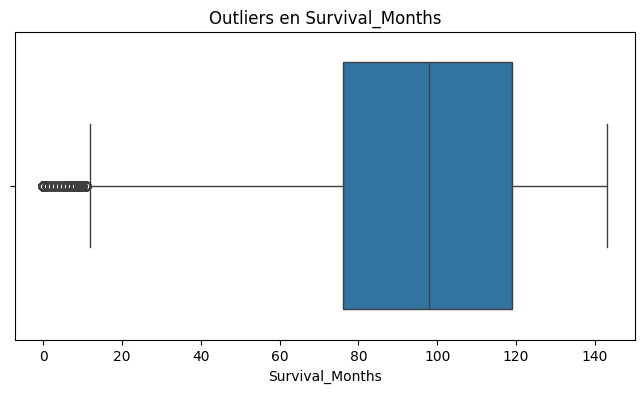

In [12]:

plt.figure(figsize=(8,4))
sns.boxplot(x=data["Age"])
plt.title("Outliers en Age")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=data["Survival_Months"])
plt.title("Outliers en Survival_Months")
plt.show()

In [13]:

def asignar_prioridad(row):
    stage = row["Stage"]
    survival = row["Survival_Months"]
    vital = row["Vital_Status"]

    if stage == "Distant":
        return "Alta"
    elif vital == "Dead" and survival < 36:
        return "Alta"
    elif stage == "Regional" and survival < 60:
        return "Alta"

    elif stage == "Regional":
        return "Media"
    elif stage in ["Localized", "In situ"] and survival < 60:
        return "Media"
    elif stage == "Unknown/unstaged":
        return "Media"
    else:
        return "Baja"


# Creación de la variable objetivo

data["Prioridad"] = data.apply(
    asignar_prioridad,
    axis=1
)

In [14]:
print(data["Prioridad"].value_counts())

Prioridad
Baja     5964
Media    3643
Alta     3563
Name: count, dtype: int64


In [15]:
top_cancers = data["Cancer_Type"].value_counts().head(15).index

# Agrupación del resto en Other

data["Cancer_Type"] = data["Cancer_Type"].apply(
    lambda x: x if x in top_cancers else "Other"
)

# ------------------------------------------------------
# Suposición:
# Las diferencias de formato textual generan categorías
# duplicadas y afectan el encoding.
# ------------------------------------------------------

# Estandarización textual

data["Cancer_Type"] = (
    data["Cancer_Type"]
    .str.strip()
    .str.lower()
)

In [16]:

y = data["Prioridad"]

In [17]:
# One-Hot Encoding

data = pd.get_dummies(
    data,
    columns=[
        "Sex",
        "Race",
        "Cancer_Type"
    ],
    drop_first=True
)

# ------------------------------------------------------
# Suposición:
# La variable Prioridad necesita representación numérica
# para clasificación supervisada.
# ------------------------------------------------------

# Codificación ordinal de Prioridad

map_prioridad = {
    "Baja": 0,
    "Media": 1,
    "Alta": 2
}


data["Prioridad"] = data["Prioridad"].map(
    map_prioridad
)

# Verificación

print(data["Prioridad"].value_counts())

Prioridad
0    5964
1    3643
2    3563
Name: count, dtype: int64


In [18]:
print(
    data["Prioridad"]
    .value_counts(normalize=True) * 100
)

Prioridad
0    45.284738
1    27.661352
2    27.053910
Name: proportion, dtype: float64


In [19]:
data.head()

,Age,Year,Stage,Survival_Months,Vital_Status,Income,Prioridad,Sex_Male,Race_Asian or Pacific Islander,Race_Black,...,Cancer_Type_c71.0-cerebrum,"Cancer_Type_c71.6-cerebellum, nos",Cancer_Type_c71.7-brain stem,"Cancer_Type_c71.9-brain, nos",Cancer_Type_c72.3-optic nerve,Cancer_Type_c73.9-thyroid gland,"Cancer_Type_c77.0-lymph nodes of head, face & neck",Cancer_Type_c77.8-lymph nodes of multiple regions,"Cancer_Type_c77.9-lymph node, nos",Cancer_Type_other
0,17.0,2016,Localized,91.0,Alive,114999.5,0,True,False,False,...,False,False,False,True,False,False,False,False,False,False
1,17.0,2015,Localized,101.0,Alive,104999.5,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,12.0,2013,Regional,122.0,Alive,104999.5,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,12.0,2013,Regional,129.0,Alive,104999.5,1,True,False,False,...,False,False,False,False,False,True,False,False,False,False
5,7.0,2012,Localized,138.0,Alive,97499.5,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [20]:
data_preprocesada = data.copy()

# Exportar dataset
data_preprocesada.to_csv(
    "data_preprocesada.csv",
    index=False
)

print("Dataset preprocesado exportado correctamente.")

Dataset preprocesado exportado correctamente.


Distribución absoluta:
Prioridad
0    5964
1    3643
2    3563
Name: count, dtype: int64

Distribución porcentual:
Prioridad
0    45.284738
1    27.661352
2    27.053910
Name: proportion, dtype: float64


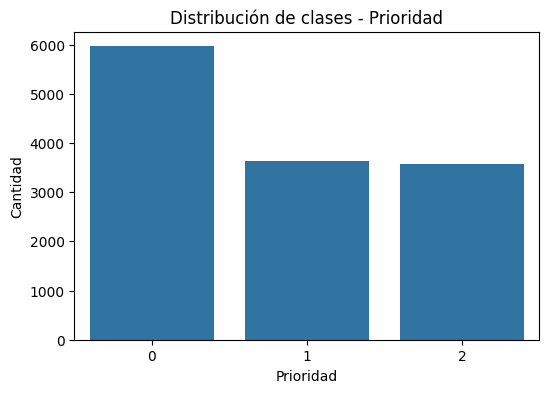


Distribución y_train:
Prioridad
0    45.282840
1    27.657555
2    27.059605
Name: proportion, dtype: float64

Distribución y_test:
Prioridad
0    45.292331
1    27.676538
2    27.031131
Name: proportion, dtype: float64


In [22]:
# ======================================================
# MANEJO DE DESBALANCEO
# ======================================================

# ------------------------------------------------------
# Suposición:
# Antes de entrenar el modelo es importante verificar
# si las clases de la variable objetivo presentan
# desbalance significativo.
# ------------------------------------------------------

# Distribución absoluta de clases

print("Distribución absoluta:")
print(data["Prioridad"].value_counts())

# Distribución porcentual

print("\nDistribución porcentual:")
print(
    data["Prioridad"]
    .value_counts(normalize=True) * 100
)

# ------------------------------------------------------
# Visualización del balance de clases
# ------------------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x=data["Prioridad"]
)

plt.title("Distribución de clases - Prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Cantidad")

plt.show()

# ------------------------------------------------------
# Suposición:
# Aunque existe una ligera diferencia entre clases,
# el desbalance no es extremo.
#
# Debido a ello:
# - No se aplicará oversampling.
# - No se aplicará undersampling.
# - No se aplicará SMOTE.
#
# Además, Random Forest tolera relativamente bien
# distribuciones moderadamente desbalanceadas.
# ------------------------------------------------------

# ------------------------------------------------------
# División estratificada
# ------------------------------------------------------

from sklearn.model_selection import train_test_split

# Suposición:
# Se utilizará estratificación para mantener la
# proporción original de clases en train y test.

# Variables predictoras
X = data.drop(columns=["Prioridad"])

# Variable objetivo
y = data["Prioridad"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificación de proporciones

print("\nDistribución y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True) * 100)

In [ ]:
# ------------------------------------------------------
# Interpretación de resultados
# ------------------------------------------------------
#
# La clase 0 (Prioridad Baja) representa aproximadamente
# el 45% de los registros totales.
#
# Las clases 1 y 2 presentan proporciones cercanas al 27%,
# mostrando una distribución relativamente equilibrada.
#
# Aunque existe una ligera predominancia de la clase 0,
# el desbalance no es suficientemente severo como para
# requerir técnicas de remuestreo.
#
# Además, tras aplicar stratify=y en train_test_split,
# las proporciones se conservaron prácticamente iguales
# tanto en entrenamiento como en prueba.
#
# Esto garantiza que el modelo aprenda bajo una
# distribución representativa del problema clínico real.
# ------------------------------------------------------